**YOUR NAME**

CS 252: Mathematical Data Analysis and Visualization

# Lab 3 | Logical Indexing and K-means Clustering

In this lab, we will be working with the UCI Seed dataset, which consists of physical measurements of different varieties of wheat seeds. Each sample corresponds to measurements of one particular wheat seed (210 total samples). There are 3 different wheat seed varieties ("Kama", "Rosa" and "Canadian").

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2

np.set_printoptions(suppress=True, precision=5)

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.figsize': [12, 5]})


## Task 1: Logical indexing

In this task, you will practice NumPy's powerful **logical indexing** technique to select data based on a specific categorical data value.

### 1a. Load in the Seed dataset

1. Read the Seeds dataset from `data/seeds.csv` using [numpy.genfromtxt](https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html#numpy-genfromtxt) or [numpy.loadtxt](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) into a numpy ndarray with 8 columns.
2. Print out the shape of your ndarray. It should be `(210, 8)`.
3. Create another ndarray that consists of only the columns with indices `0`, `5`, and `7`. Print the shape of the new ndarray, it should be `(210, 3)`.
    - Column 0 corresponds to the measured area of a wheat seed  (i.e. `length x width`)
    - Column 5 corresponds to the measured asymmetry in the shape of a wheat seed.
    - Column 7 corresponds to the wheat seed variety, a categorical variable that has been int-coded for you.: 0:`kama`, 1:`rosa`, 2:canadian`.
    - The list of the variable string names and the `cat2levels` dictionary that maps between int-coded and string-coded seed variety levels are provided below.
4. Print out the 1st 5 rows of the smaller ndarray that you created. You should see:

```
[[15.26   2.221  0.   ]
 [14.88   1.018  0.   ]
 [14.29   2.699  0.   ]
 [13.84   2.259  0.   ]
 [16.14   1.355  0.   ]]
```

In [2]:
# KEEP ME
seed_vars = ['area', 'asymmetry', 'variety']
cat2levels = {'variety': ['kama', 'rosa', 'canadian']}

In [3]:
#1
# YOUR CODE HERE
d = np.genfromtxt("data/seeds.csv", delimiter=",", skip_header=1)
d_sub = d[:, [0, 5, 7]]

print(d_sub[:5])

[[15.26   2.221  0.   ]
 [14.88   1.018  0.   ]
 [14.29   2.699  0.   ]
 [13.84   2.259  0.   ]
 [16.14   1.355  0.   ]]


### 1b. Use logical indexing to count the number of 0 values in an 1D ndarray


In one line of code, use logical indexing to count and print the number of 0s in `test_data`, which contains 1D fake data with `N=100` samples. You should get a count of `20` 0s.

This involves creating a **1D boolean (logical) array** by comparing your data array with a single (scalar) value using the `==` operator. For example: <br/>`my_data_array == single_value`<br/>The result of this operation is the logical array that has the same length as the original data array (100 in the case of `test_data` below): an entry is `True` (1) if the i-th value matches your desired value (e.g. `0`) or `False` (0) if the i-th value does not. The count can be computed by summing up the logical array.<br/><br/>**Note:** You should not use any loops!

In [4]:
# KEEP ME
test_data = np.array([1, 0, 1, 4, 1, 4, 0, 2, 4, 4, 3, 2, 1, 0, 3, 4, 1, 4, 2, 4, 2, 4,
       0, 0, 3, 1, 2, 2, 4, 2, 0, 2, 0, 4, 0, 3, 2, 3, 4, 4, 4, 4, 1, 3,
       2, 3, 1, 3, 1, 1, 1, 0, 1, 4, 4, 0, 0, 2, 1, 4, 1, 3, 3, 1, 3, 2,
       1, 0, 4, 1, 1, 1, 0, 0, 3, 0, 2, 2, 4, 0, 2, 2, 4, 4, 2, 3, 2, 1,
       0, 2, 2, 1, 1, 1, 4, 0, 0, 1, 0, 4])



In [5]:
sum([1 for t in test_data == 0 if t == True])

20

### 1c. Use logical indexing to count the number of samples that belong to the each of the 3 wheat seed varieties

1. Create a ndarray filled with 3 zeros. This array will store the number of samples that belong to each of the 3 wheat seed varieties (remember: they are int-coded as `0`, `1`, and `2`).
2. In only 1 line of code per variety (**at most** 3 lines total), compute the counts for each variety using logical indexing and assign the count to the appropriate index of your length 3 ndarray. In this case, the logical array has entries of `True` (1) if the `variety` categorical variable value of a sample has the desired level (e.g. `0` if we are counting `kama` seed variety) or `False` (0) if the sample does not.
3. Print out your counts for the 3 seed varieties. You should get `[70. 70. 70.].`

In [6]:
# YOUR CODE HERE

seed_variety_col = d_sub[:, 2]

seeds = np.array([0,0,0])

# wait this is hilarious
seeds = [sum([1 for t in seed_variety_col == i if t == True]) for i in range(3)]

# seeds[0] = sum([1 for t in seed_variety_col == 0 if t == True])
# seeds[1] = sum([1 for t in seed_variety_col == 1 if t == True])
# seeds[2] = sum([1 for t in seed_variety_col == 2 if t == True])
print(seeds)

[70, 70, 70]


### 1d. Use logical indexing to select the asymmetry of only the 'rosa' wheat seed variety

1. Similar to what you did in Task 1c, create a 1D logical array that indicates whether samples belong to the `'rosa'` wheat seed variety (int-coded as `1`).
2. Index into the pared down seed dataset 2D ndarray (the one with shape: `(210, 3)`), plugging in the logical array as the ROWS (instead of typing :). For the COLUMN, select the column index (an int) that is appropriate for the variable we are interested in (`asymmetry`).
3. Print out the result. There should be `70` float values. **What is the meaning of these values?**

In [7]:
# YOUR CODE HERE
seed_asymetry_col = d_sub[:, 2] == 1
all_samples_of_rosea = d_sub[seed_asymetry_col, 1]
print(all_samples_of_rosea.shape)

# the 70 variables here are all the asymetry data points (d_sub[:, 1] or d[:, 5]) for any wheat seed that is marked as Rosa


(70,)


### 1e. Use logical indexing to filter the dataset

Index into the pared down seed dataset 2D ndarray (the one with shape: `(210, 3)`) and plug in the same logical array from Task 1d for the ROWS, but this time omit/do NOT specify any COLUMN. **Print out and interpret what you get.**

In [8]:
# YOUR CODE HERE
print(d_sub[seed_asymetry_col, :])

# like I suspected, it's getting all samples that are of type Rosa

[[17.63   4.076  1.   ]
 [16.84   4.675  1.   ]
 [17.26   4.539  1.   ]
 [19.11   2.936  1.   ]
 [16.82   4.004  1.   ]
 [16.77   4.92   1.   ]
 [17.32   3.824  1.   ]
 [20.71   4.451  1.   ]
 [18.94   5.064  1.   ]
 [17.12   2.858  1.   ]
 [16.53   5.532  1.   ]
 [18.72   5.324  1.   ]
 [20.2    5.173  1.   ]
 [19.57   1.472  1.   ]
 [19.51   2.962  1.   ]
 [18.27   2.443  1.   ]
 [18.88   1.649  1.   ]
 [18.98   3.691  1.   ]
 [21.18   5.78   1.   ]
 [20.88   5.016  1.   ]
 [20.1    1.955  1.   ]
 [18.76   3.12   1.   ]
 [18.81   3.237  1.   ]
 [18.59   6.001  1.   ]
 [18.36   4.933  1.   ]
 [16.87   3.696  1.   ]
 [19.31   3.477  1.   ]
 [18.98   2.144  1.   ]
 [18.17   2.853  1.   ]
 [18.72   2.188  1.   ]
 [16.41   4.217  1.   ]
 [17.99   2.068  1.   ]
 [19.46   4.308  1.   ]
 [19.18   3.357  1.   ]
 [18.95   3.368  1.   ]
 [18.83   2.553  1.   ]
 [18.85   2.843  1.   ]
 [17.63   3.747  1.   ]
 [19.94   3.252  1.   ]
 [18.55   1.738  1.   ]
 [18.45   2.235  1.   ]
 [19.38   3.678 

### 1f. Use logical indexing to compute the mean area for each of the 3 wheat seed varieties

1. Create a ndarray named `means` filled with 3 zeros. This array will store the mean area of each of the 3 wheat seed varieties.
2. Adapt what you did in Task 1c to fill in the mean area of each seed variety using logical indexing. You should only write 1 line of code per species (**at most 3 lines of code for computing means, no loops!!**).

You should get: `[14.33443 18.33429 11.87386]`

In [22]:
# This is funny
print([float(np.mean([d_sub[:, 0][d_sub[:, 2] == i]])) for i in range(3)])

[14.334428571428571, 18.334285714285713, 11.873857142857144]


### 1g. Visualize the area and asymmetry of different seed varieties

4. Create a list of color-blind friendly hard-coded RGB colors that will be used to color samples that belong to the same cluster. Pick either the [Okabe & Ito or one of the Petroff color palettes](https://github.com/proplot-dev/proplot/issues/424) (*These lists have been studied to be effective for colorblind individuals*). Your list of color strings should be at least as long as the number of clusters you select. Since there are 3 in this lab, any of the color palettes will work. *Each string is represented as a [hexadecimal color code](https://en.wikipedia.org/wiki/Web_colors)*.
5. Graph a scatter plot of the `area` and `asymmetry` columns using `plt.scatter`
    1. Write a loop that runs for 3 iterations (one for each seed variety).
    2. Inside the loop, use logical indexing to select rows in the ndarray that have the current wheat seed variety level. Assign this 'filtered' ndarray to a temp variable. If everything is working as expected, you should have `70`, `70`, and `70` samples for the varieties `'kama'`, `'rosa'`, `'canadian'`, respectively.
    3. Plot `area` on the x axis and `asymmetry` on the y axis from the **filtered** ndarray with markers that have a black edgecolor. Set the color to one of the strings from your hard-coded list of colors.
    4. Add a useful title, and axis labels.

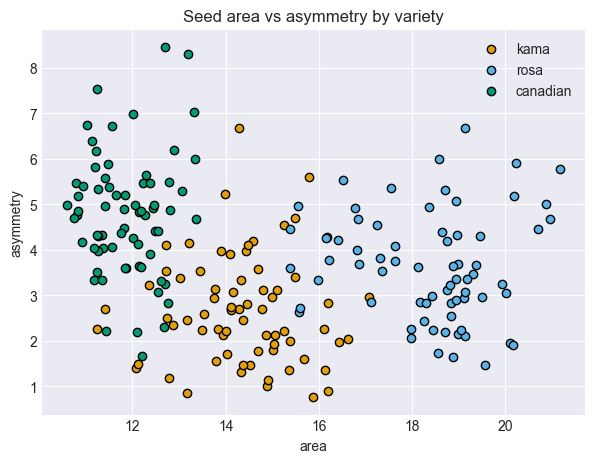

In [27]:
# YOUR CODE HERE
colors = ["#E69F00", "#56B4E9", "#009E73"]
cat2levels = {"variety": ["kama", "rosa", "canadian"]}

plt.figure(figsize=(7, 5))
for i in range(3):
    mask = d_sub[:, 2] == i
    filtered = d_sub[mask]
    plt.scatter(
        filtered[:, 0],
        filtered[:, 1],
        c=colors[i],
        edgecolors="black",
        label=cat2levels["variety"][i],
    )
plt.xlabel("area")
plt.ylabel("asymmetry")
plt.title("Seed area vs asymmetry by variety")
plt.legend()
plt.show()

## Task 2: K-Means

1. Use the [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.vq.kmeans2.html) documentation to find out how to calculate K-Means on for the columns `area` and `asymmetry` using  `kmeans2`. Use 3 clusters and set the method of initialization to random. 
2. Calculate the **inertia**: how closely packed samples are around their cluster centroids in the current clustering.
    1. For each data sample calculate the **squared** euclidean distance between that sample and its cluster centroid. Average these values across all samples.
    2. Print the inertia.
3. Graph the results of the clustering next in a plot next to the actual data. (2 subplots)
    1. Graph `'area'` on the x axis and `'asymmetry'` on the y axis
    2. Have a title for each subplot, and axis labels.
    3. Graph the original data following the instructions from Part 1 in the first subplot. 
        1. Use the `variety` column of your data for the color with a black edgecolor
    4. Graph the results of K-means in the second subplot. [See example](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.vq.kmeans2.html)
        1. Graph the data colored by the clusters with the centroids labeled. Use your colorblind-friendly custom color palette to color each of the three clusters.

You should get an inertia of ~`2.45`.


Inertia: 2.452658058291693


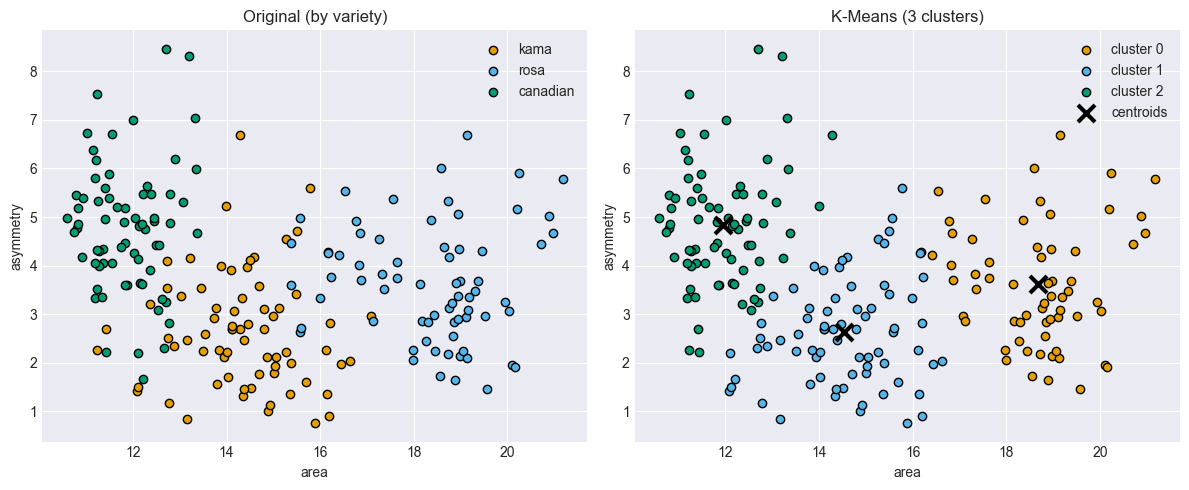

In [28]:
np.random.seed(3)  # KEEP ME

from scipy.cluster.vq import kmeans2

# 1. K-Means on area and asymmetry, 3 clusters, random init
X_km = d_sub[:, [0, 1]]  # area (col 0), asymmetry (col 1)
centroids, labels = kmeans2(X_km, 3, minit="random")

# 2. Inertia: mean of squared euclidean distance from each point to its centroid
squared_dists = np.sum((X_km - centroids[labels]) ** 2, axis=1)
inertia = np.mean(squared_dists)
print(f"Inertia: {inertia}")

# 3. Two subplots: original (by variety) and K-means (by cluster)
colors = ["#E69F00", "#56B4E9", "#009E73"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: original data colored by variety (same as 1g)
for i in range(3):
    mask = d_sub[:, 2] == i
    ax1.scatter(d_sub[mask, 0], d_sub[mask, 1], c=colors[i], edgecolors="black", label=["kama", "rosa", "canadian"][i])
ax1.set_xlabel("area")
ax1.set_ylabel("asymmetry")
ax1.set_title("Original (by variety)")
ax1.legend()

# Right: K-means result, colored by cluster, centroids labeled
for i in range(3):
    mask = labels == i
    ax2.scatter(X_km[mask, 0], X_km[mask, 1], c=colors[i], edgecolors="black", label=f"cluster {i}")
ax2.scatter(centroids[:, 0], centroids[:, 1], c="black", s=150, marker="x", linewidths=3, label="centroids")
ax2.set_xlabel("area")
ax2.set_ylabel("asymmetry")
ax2.set_title("K-Means (3 clusters)")
ax2.legend()
plt.tight_layout()
plt.show()

## Task 3: Analysis

1. Write code that calculates the kmeans2 50 times
2. Save the centroids, labels and inertia for each clustering instance.

*Note: Ignore if you get a UserWarning.*

C:\Users\micke\AppData\Roaming\Python\Python313\site-packages\scipy\_lib\_util.py:365: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


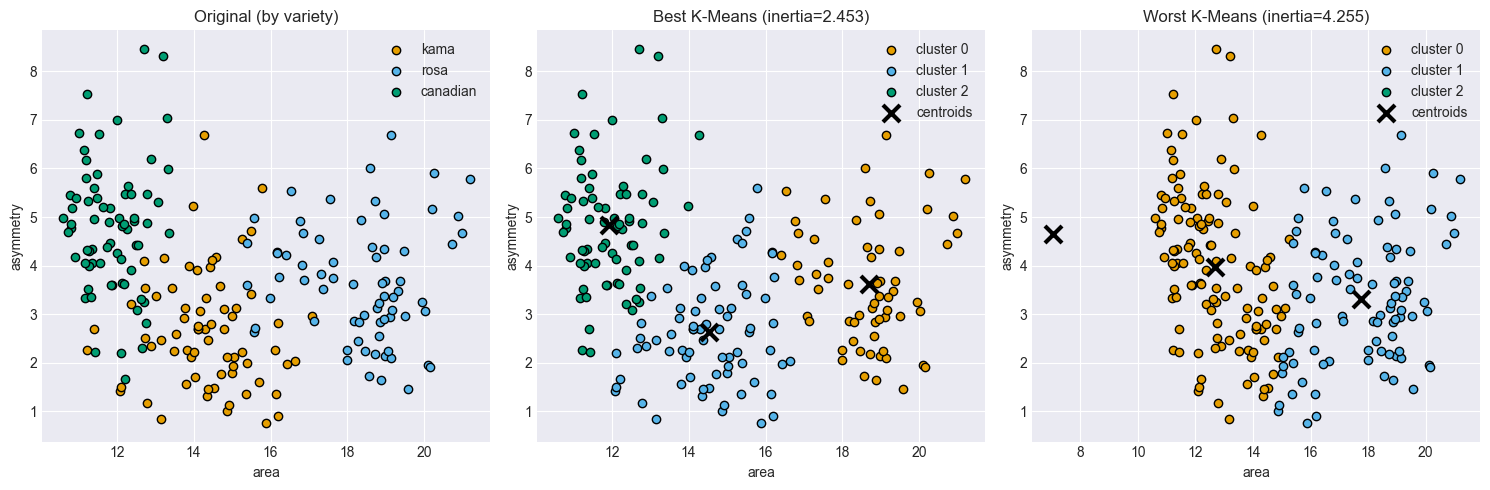

In [29]:
np.random.seed(3)  # KEEP ME

from scipy.cluster.vq import kmeans2

X_km = d_sub[:, [0, 1]]
n_runs = 50
all_centroids = []
all_labels = []
all_inertias = []

for _ in range(n_runs):
    centroids, labels = kmeans2(X_km, 3, minit="random")
    squared_dists = np.sum((X_km - centroids[labels]) ** 2, axis=1)
    inertia = np.mean(squared_dists)
    all_centroids.append(centroids)
    all_labels.append(labels)
    all_inertias.append(inertia)

all_inertias = np.array(all_inertias)
best_idx = np.argmin(all_inertias)
worst_idx = np.argmax(all_inertias)
best_centroids, best_labels = all_centroids[best_idx], all_labels[best_idx]
worst_centroids, worst_labels = all_centroids[worst_idx], all_labels[worst_idx]

colors = ["#E69F00", "#56B4E9", "#009E73"]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original (by variety)
for i in range(3):
    mask = d_sub[:, 2] == i
    ax1.scatter(d_sub[mask, 0], d_sub[mask, 1], c=colors[i], edgecolors="black", label=["kama", "rosa", "canadian"][i])
ax1.set_xlabel("area")
ax1.set_ylabel("asymmetry")
ax1.set_title("Original (by variety)")
ax1.legend()

# Best K-Means
for i in range(3):
    mask = best_labels == i
    ax2.scatter(X_km[mask, 0], X_km[mask, 1], c=colors[i], edgecolors="black", label=f"cluster {i}")
ax2.scatter(best_centroids[:, 0], best_centroids[:, 1], c="black", s=150, marker="x", linewidths=3, label="centroids")
ax2.set_xlabel("area")
ax2.set_ylabel("asymmetry")
ax2.set_title(f"Best K-Means (inertia={all_inertias[best_idx]:.3f})")
ax2.legend()

# Worst K-Means
for i in range(3):
    mask = worst_labels == i
    ax3.scatter(X_km[mask, 0], X_km[mask, 1], c=colors[i], edgecolors="black", label=f"cluster {i}")
ax3.scatter(worst_centroids[:, 0], worst_centroids[:, 1], c="black", s=150, marker="x", linewidths=3, label="centroids")
ax3.set_xlabel("area")
ax3.set_ylabel("asymmetry")
ax3.set_title(f"Worst K-Means (inertia={all_inertias[worst_idx]:.3f})")
ax3.legend()
plt.tight_layout()
plt.show()

3. Graph a plot with 3 subplots
    1. **Original:** The first plot should graph Graph `'area'` on the x axis and `'asymmetry'` on the y axis with the original labels
    2. **Best clustering:** Using your above analysis the second plot should graph the results with the **best** K-Means fit using the saved labels and centroids from the above analysis.
    3. **Worst clustering:** Using your above analysis the third plot should graph the results with the worst K-Means fit using the saved labels and centroids from the above analysis.
    4. For formatting, follow the instructions in Task 2.

### Questions

**Question 1:** Why does kmeans produce different solutions?

**Question 2:** What is going on with the worst clustering case? Why are the results so bad?

**Answer 1:**

YOUR ANSWER HERE

 K-Means gives different solutions because it starts from random initial centroids (minit="random"). Each run can begin at a different place, and the algorithm only finds a local minimum of the inertia (sum of squared distances to centroids). So different initializations can converge to different local minima, and therefore to different clusterings and different inertia values.

**Answer 2:**

YOUR ANSWER HERE

The worst run is bad because it got stuck in a poor local minimum. With random initialization, some runs start with centroids in unlucky positions (e.g., several in one region or far from the main data). The algorithm then only improves that starting point a little, so the final clusters can be unbalanced (e.g., one huge cluster, others tiny) or cut across natural groups. That shows up as high inertia and a messy-looking plot where clusters don’t match the three seed varieties well.

## Turn in your notebook to Google Classroom